##Menetukan Pertanyaan Bisnis

###Pertanyaan 1 : Kota administrasi mana yang memiliki jumlah laporan kerusakan infrastruktur tertinggi sepanjang tahun 2025, dan berapa persentase kontribusinya terhadap total keseluruhan laporan?

keterangan :


*   **Spesific** : Fokus pada perbandingan volume laporan per kota
*   **Measurable** : Jumlah laporan dan persentase kontribusi per kota
*   **Action - Oriented** : Dengan mengetahui kota administrasi mana yang paling banyak laporan kerusakan, dapat menentukan prioritas alokasi anggaran perbaikan per wilayah
*   **Relevant** : Volume laporan mencerminkan beban kebutuhan perbaikan infrastruktur di suatu wilayah
*   **Time-bound** : Dibatasi pada tahun 2025

###Pertanyaan 2 : Berapa rata-rata jumlah laporan infrastruktur yang masuk per bulan di seluruh kota administrasi Jakarta sepanjang tahun 2025, dan bulan apa yang mencatatkan volume laporan tertinggi

keterangan :


*   **Spesific** : Fokus pada tren bulanan volume laporan
*   **Measurable** : Rata-rata laporan/bulan dan identifikasi bulan puncak
*   **Action - Oriented** : Merencanakan kapasitas tim lapangan di bulan sibuk
*   **Relevant** : Membantu perencanaan sumber daya operasional
*   **Time-bound** : Sepanjang tahun 2025 (bulan januari-Desember)

###Pertanyaan 3 : Jenis infrastruktur apa yang paling sering dilaporkan mengalami kerusakan berat di seluruh kota administrasi Jakarta selama semester pertama (Januari-Juni) 2025?

keterangan :


*   **Spesific** : Fokus pada kerusakan berat per jenis infrastruktur
*   **Measurable** : Jumlah laporan kerusakan berat per jenis infrastruktur
*   **Action - Oriented** : Prioritas program pemeliharaan preventif pada jenis tertentu
*   **Relevant** : Kerusakan berat berbiaya tinggi, perlu prioritas anggaran
*   **Time-bound** : Sepanjang tahun 2025

###Pertanyaan 4 : Berapa jumlah laporan kerusakan infrastruktur Trotoar di Jakarta Selatan yang berstatus berat pada periode Juli-Desember 2025 dibandingkan periode Januari-Juni 2025?

keterangan :


*   **Spesific** : Fokus pada menganalisis trotoar dengan tingkat kerusakan berat pada dua semester
*   **Measurable** : Perbandingan jumlah laporan jenis infrastruktur dengan tingkat kerusakan berat di 6 bulan pertama dan 6 bulan kedua
*   **Action - Oriented** : Evaluasi efektivitas program perbaikan trotoar di semester pertama
*   **Relevant** : Trotoar berkaitan dengan keselamatan pejalan kaki
*   **Time-bound** : 6 bulan pertama dan 6 bulan kedua di tahun 2025





## Import Semua Packages/Library yang Digunakan

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re

#Mengatur ukuran default grafik menjadi 12 inci lebar × 6 inci tinggi.
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid')

## Data Wrangling

### Gathering Data

#### Load data

In [40]:
df = pd.read_csv('/content/Data_Laporan_Infrastruktur_Kotor.csv')
df.head()

,id,deskripsi_laporan,jenis_infrastruktur,kota_administrasi,tingkat_kerusakan,date_laporan
0,1,Ada celah kecil di aspal jalan dekat Jalan Ahm...,Jalan,Jakarta Pusat,Ringan,2025-11-04 00:47:17
1,2,Jalan Jalan Pluit berlubng cukup dalam sekitar...,Jalan,Jakarta Timur,Sedang,2025-04-08 04:47:06
2,3,Trotoar Jalan Ahmad Yani perlu pengecatan ulan...,Trotoar,Kepulauan Seribu,Ringan,2025-11-24 17:05:37
3,4,Lampu penerangan di Jalan TB Simatupang kurang...,Lampu Jalan,Jakarta Timur,Ringan,2025-07-02 00:05:13
4,5,Kabel fiber Jalan Hayam Wuruk tergantung renda...,Kabel Fiber,Jakarta Barat,Sedang,2025-04-17 19:01:35


### Assessing Data

####Identifying Data Type Problem

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14000 entries, 0 to 13999
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id                   14000 non-null  int64 
 1   deskripsi_laporan    14000 non-null  object
 2   jenis_infrastruktur  14000 non-null  object
 3   kota_administrasi    14000 non-null  object
 4   tingkat_kerusakan    14000 non-null  object
 5   date_laporan         14000 non-null  object
dtypes: int64(1), object(5)
memory usage: 656.4+ KB


#### Identifying Missing Value problem



In [42]:
df.isna().sum()

,0
id,0
deskripsi_laporan,0
jenis_infrastruktur,0
kota_administrasi,0
tingkat_kerusakan,0
date_laporan,0


#### Identifying duplicate data problem

In [43]:
print("Jumlah duplikasi", df.duplicated().sum())

Jumlah duplikasi 0


####identifting inconsitency data problem

In [44]:
print("=== Unique values per kolom kategorikal ===")
for col in df.select_dtypes(include='object').columns:
    unique_vals = df[col].str.strip().str.lower().unique() if df[col].dtype == 'object' else df[col].unique()
    print(f"\n[{col}] ({len(unique_vals)} unique):")
    print(sorted([str(v) for v in unique_vals if pd.notna(v)]))

=== Unique values per kolom kategorikal ===

[deskripsi_laporan] (7835 unique):
['ada  celah  kecil  di  aspal  jalan  dekat  jalan  raya  bekasi', 'ada  sedikit  sampah  di  area  taman  jalan  sudirman', 'ada celah kecil di aspal jalan dekat gang anggrek', 'ada celah kecil di aspal jalan dekat gang dahlia', 'ada celah kecil di aspal jalan dekat gang mawar', 'ada celah kecil di aspal jalan dekat gang melati', 'ada celah kecil di aspal jalan dekat jalan ahmad yani', 'ada celah kecil di aspal jalan dekat jalan ahmad yani 🙏', 'ada celah kecil di aspal jalan dekat jalan casablanca', 'ada celah kecil di aspal jalan dekat jalan ciledug raya 🙏', 'ada celah kecil di aspal jalan dekat jalan daan mogot', 'ada celah kecil di aspal jalan dekat jalan fatmawati', 'ada celah kecil di aspal jalan dekat jalan gajah mada', 'ada celah kecil di aspal jalan dekat jalan gatot subroto', 'ada celah kecil di aspal jalan dekat jalan gunung sahari', 'ada celah kecil di aspal jalan dekat jalan haji nawi', 'ada c

#### Identifying punctuation problem

In [45]:
def has_punctuation_issue(text):
    return bool(re.search(r'[!?,;.]{2,}', str(text)))

punct_mask = df['deskripsi_laporan'].dropna().apply(has_punctuation_issue)
punct_issues = df.loc[punct_mask.index[punct_mask]]

print(f"Total baris dengan masalah tanda baca berulang: {len(punct_issues)}")
print("\nContoh:")
print(punct_issues['deskripsi_laporan'].head(5).tolist())

Total baris dengan masalah tanda baca berulang: 138

Contoh:
['URGENT!! Got Jalan Gajah Mada retak dan bocor air merembes ke jlan', 'URGENT!! Beberapa tanaman di taman Jalan Hayam Wuruk layu perlu disiram', 'Jembatan Jalan Sudirman retak parah dan sagnat berbahaya harus ditutup...', 'Taman Jalan Panjang kondisi sangat kritis semua tanaman mati dan fasilitas hancur... depan masjid', 'Trotoar Jalan Casablanca tidak bisa digunakan sama sekali kondisi darurat!!']


####Identifying special characters

In [46]:
def has_special_char(text):
    return bool(re.search(r'[^\x00-\x7F]', str(text)))

special_mask = df['deskripsi_laporan'].dropna().apply(has_special_char)
special_issues = df.loc[special_mask.index[special_mask]]

print(f"Total baris dengan karakter khusus (non-ASCII/emoji): {len(special_issues)}")
print("\nContoh:")
print(special_issues['deskripsi_laporan'].head(5).tolist())

Total baris dengan karakter khusus (non-ASCII/emoji): 70

Contoh:
['Kap lampu jalan di Jalan Gajah Mada kotor mengurangi pencahayaan 🙏', 'Drainase Jalan Pramuka tersumbat menyebabkan genangan air saat hujan 🙏', 'Lampu jlan Jalan Cengkareng cahayanya mulai memudar 🙏', 'Jembatan Jalan TB Simatupang ada bagian yang ambles tidak rata 🙏', 'Beberapa bata trotoar jl Rasuna Said retak ringan 🙏']


####Identifying extra space problem

In [47]:
def has_extra_space(text):
    return '  ' in str(text) or str(text) != str(text).strip()

for col in df.select_dtypes(include=['object']).columns:
    mask  = df[col].dropna().apply(has_extra_space)
    count = mask.sum()
    print(f"[{col}] — {count} baris dengan extra space")
    if count > 0:
        print("  Contoh:", df[col][mask.index[mask]].head(3).tolist())

[deskripsi_laporan] — 67 baris dengan extra space
  Contoh: ['Lampu  jalan  Jalan  Panjang  sering  konslet  menyebabkan  mati  berulang', 'Drainase  Jalan  Raya  Pasar  Minggu  tersumbat  menyebabkan  genangan  air  saat  hujan', 'Cat  jembatan  di  Jalan  Meruya  mulai  mengelupas  perlu  dicat  ulang']
[jenis_infrastruktur] — 0 baris dengan extra space
[kota_administrasi] — 0 baris dengan extra space
[tingkat_kerusakan] — 0 baris dengan extra space
[date_laporan] — 0 baris dengan extra space


####Identifying capitalize problem

In [48]:
import re

# Fungsi untuk mengecek apakah ada huruf kapital
def has_uppercase(text):
    return bool(re.search(r'[A-Z]', str(text)))

# Terapkan ke kolom deskripsi_laporan
upper_mask = df['deskripsi_laporan'].dropna().apply(has_uppercase)

# Ambil baris yang mengandung huruf kapital
upper_issues = df.loc[upper_mask.index[upper_mask]]

# Tampilkan jumlah baris
print(f"Total baris yang mengandung huruf kapital: {len(upper_issues)}")

# Tampilkan beberapa contoh
print("\nContoh:")
for ex in upper_issues['deskripsi_laporan'].head(10).tolist():
    print(" -", ex)

Total baris yang mengandung huruf kapital: 14000

Contoh:
 - Ada celah kecil di aspal jalan dekat Jalan Ahmad Yani
 - Jalan Jalan Pluit berlubng cukup dalam sekitar 5 cm
 - Trotoar Jalan Ahmad Yani perlu pengecatan ulang marka sudah pudar
 - Lampu penerangan di Jalan TB Simatupang kurang terang perlu diganti
 - Kabel fiber Jalan Hayam Wuruk tergantung rendah bahaya bgt bagi kendaraan tinggi
 - Ubin trotoar di Jalan Sisingamangaraja mulai longgar tapi masih aman
 - Trotoar Jalan Casablanca berlubang dan berbahaya bagi pejalan kaki
 - Taman Jalan Raya Pasar Minggu banyak vandalisme coretan di fasilitas umum
 - Got Jalan Ciledug Raya ada sedikit sampah yang menghambat aliran air
 - Rel pagar jembatan di Jalan Ciledug Raya berkarat perlu perawatan


**Steps to Take:**
- Mengganti tipe data kolom date_laporan dari object menjadi datetime
- Mentransformasi kolom tingkat kerusakan menjadi label encoder
- Menghapus tanda baca
- menormalisasikan kapitalisasi pada kolom deskripsi laporan menjadi lower case
- Menghapus spasi berlebih pada kolom deskripsi_laporan
- Menghapus fitur id karena tidak relevan dalam analisis

### Cleaning Data

#### Fixing data type problem

In [49]:
df['date_laporan'] = pd.to_datetime(df['date_laporan'])

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14000 entries, 0 to 13999
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   id                   14000 non-null  int64         
 1   deskripsi_laporan    14000 non-null  object        
 2   jenis_infrastruktur  14000 non-null  object        
 3   kota_administrasi    14000 non-null  object        
 4   tingkat_kerusakan    14000 non-null  object        
 5   date_laporan         14000 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(4)
memory usage: 656.4+ KB


#### Fixing damage encoding problem

In [51]:
mapping = {
    'Ringan': 0,
    'Sedang': 1,
    'Berat': 2
}

df['tingkat_kerusakan_encoded'] = df['tingkat_kerusakan'].map(mapping)

In [52]:
df.head(10)

,id,deskripsi_laporan,jenis_infrastruktur,kota_administrasi,tingkat_kerusakan,date_laporan,tingkat_kerusakan_encoded
0,1,Ada celah kecil di aspal jalan dekat Jalan Ahm...,Jalan,Jakarta Pusat,Ringan,2025-11-04 00:47:17,0
1,2,Jalan Jalan Pluit berlubng cukup dalam sekitar...,Jalan,Jakarta Timur,Sedang,2025-04-08 04:47:06,1
2,3,Trotoar Jalan Ahmad Yani perlu pengecatan ulan...,Trotoar,Kepulauan Seribu,Ringan,2025-11-24 17:05:37,0
3,4,Lampu penerangan di Jalan TB Simatupang kurang...,Lampu Jalan,Jakarta Timur,Ringan,2025-07-02 00:05:13,0
4,5,Kabel fiber Jalan Hayam Wuruk tergantung renda...,Kabel Fiber,Jakarta Barat,Sedang,2025-04-17 19:01:35,1
5,6,Ubin trotoar di Jalan Sisingamangaraja mulai l...,Trotoar,Jakarta Utara,Ringan,2025-04-23 20:44:34,0
6,7,Trotoar Jalan Casablanca berlubang dan berbaha...,Trotoar,Jakarta Selatan,Sedang,2025-07-08 14:37:17,1
7,8,Taman Jalan Raya Pasar Minggu banyak vandalism...,Taman,Jakarta Timur,Sedang,2025-01-25 05:44:27,1
8,9,Got Jalan Ciledug Raya ada sedikit sampah yang...,Drainase,Jakarta Barat,Ringan,2025-06-09 04:13:48,0
9,10,Rel pagar jembatan di Jalan Ciledug Raya berka...,Jembatan,Kepulauan Seribu,Ringan,2025-06-04 02:24:06,0


#### Fixing punctuation problem

In [53]:
import string

def remove_punctuation(text):
    text = str(text)
    return text.translate(str.maketrans('', '', string.punctuation))

df['deskripsi_laporan'] = df['deskripsi_laporan'].apply(remove_punctuation)


In [54]:
print("Contoh setelah penghapusan tanda baca:")
print(df['deskripsi_laporan'].head().tolist())

Contoh setelah penghapusan tanda baca:
['Ada celah kecil di aspal jalan dekat Jalan Ahmad Yani', 'Jalan Jalan Pluit berlubng cukup dalam sekitar 5 cm', 'Trotoar Jalan Ahmad Yani perlu pengecatan ulang marka sudah pudar', 'Lampu penerangan di Jalan TB Simatupang kurang terang perlu diganti', 'Kabel fiber Jalan Hayam Wuruk tergantung rendah bahaya bgt bagi kendaraan tinggi']


####Fixing Capitalization problem

In [55]:
df['deskripsi_laporan'] = df['deskripsi_laporan'].str.lower()
df['jenis_infrastruktur'] = df['jenis_infrastruktur'].str.lower()
df['kota_administrasi'] = df['kota_administrasi'].str.lower()
df['tingkat_kerusakan'] = df['tingkat_kerusakan'].str.lower()

In [56]:
df.head(10)

,id,deskripsi_laporan,jenis_infrastruktur,kota_administrasi,tingkat_kerusakan,date_laporan,tingkat_kerusakan_encoded
0,1,ada celah kecil di aspal jalan dekat jalan ahm...,jalan,jakarta pusat,ringan,2025-11-04 00:47:17,0
1,2,jalan jalan pluit berlubng cukup dalam sekitar...,jalan,jakarta timur,sedang,2025-04-08 04:47:06,1
2,3,trotoar jalan ahmad yani perlu pengecatan ulan...,trotoar,kepulauan seribu,ringan,2025-11-24 17:05:37,0
3,4,lampu penerangan di jalan tb simatupang kurang...,lampu jalan,jakarta timur,ringan,2025-07-02 00:05:13,0
4,5,kabel fiber jalan hayam wuruk tergantung renda...,kabel fiber,jakarta barat,sedang,2025-04-17 19:01:35,1
5,6,ubin trotoar di jalan sisingamangaraja mulai l...,trotoar,jakarta utara,ringan,2025-04-23 20:44:34,0
6,7,trotoar jalan casablanca berlubang dan berbaha...,trotoar,jakarta selatan,sedang,2025-07-08 14:37:17,1
7,8,taman jalan raya pasar minggu banyak vandalism...,taman,jakarta timur,sedang,2025-01-25 05:44:27,1
8,9,got jalan ciledug raya ada sedikit sampah yang...,drainase,jakarta barat,ringan,2025-06-09 04:13:48,0
9,10,rel pagar jembatan di jalan ciledug raya berka...,jembatan,kepulauan seribu,ringan,2025-06-04 02:24:06,0


####Fixing extra space Problem

In [57]:
df['deskripsi_laporan'] = df['deskripsi_laporan'].str.replace(r'\s+', ' ', regex=True).str.strip()

In [58]:
print("Contoh setelah penghapusan spasi berlebih:")
print(df['deskripsi_laporan'].head().tolist())

Contoh setelah penghapusan spasi berlebih:
['ada celah kecil di aspal jalan dekat jalan ahmad yani', 'jalan jalan pluit berlubng cukup dalam sekitar 5 cm', 'trotoar jalan ahmad yani perlu pengecatan ulang marka sudah pudar', 'lampu penerangan di jalan tb simatupang kurang terang perlu diganti', 'kabel fiber jalan hayam wuruk tergantung rendah bahaya bgt bagi kendaraan tinggi']


Fixing Id Problem

In [59]:
df = df.drop(columns=['id'])

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14000 entries, 0 to 13999
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   deskripsi_laporan          14000 non-null  object        
 1   jenis_infrastruktur        14000 non-null  object        
 2   kota_administrasi          14000 non-null  object        
 3   tingkat_kerusakan          14000 non-null  object        
 4   date_laporan               14000 non-null  datetime64[ns]
 5   tingkat_kerusakan_encoded  14000 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(4)
memory usage: 656.4+ KB


In [61]:
df.head()

,deskripsi_laporan,jenis_infrastruktur,kota_administrasi,tingkat_kerusakan,date_laporan,tingkat_kerusakan_encoded
0,ada celah kecil di aspal jalan dekat jalan ahm...,jalan,jakarta pusat,ringan,2025-11-04 00:47:17,0
1,jalan jalan pluit berlubng cukup dalam sekitar...,jalan,jakarta timur,sedang,2025-04-08 04:47:06,1
2,trotoar jalan ahmad yani perlu pengecatan ulan...,trotoar,kepulauan seribu,ringan,2025-11-24 17:05:37,0
3,lampu penerangan di jalan tb simatupang kurang...,lampu jalan,jakarta timur,ringan,2025-07-02 00:05:13,0
4,kabel fiber jalan hayam wuruk tergantung renda...,kabel fiber,jakarta barat,sedang,2025-04-17 19:01:35,1


##Exploratory Data Analysis

###Explore Data

In [62]:
df.describe(include='all')

,deskripsi_laporan,jenis_infrastruktur,kota_administrasi,tingkat_kerusakan,date_laporan,tingkat_kerusakan_encoded
count,14000,14000,14000,14000,14000,14000.000000
unique,7757,7,6,3,NaN,NaN
top,jembatan jalan hayam wuruk ambles parah dan me...,jalan,kepulauan seribu,ringan,NaN,NaN
freq,8,2000,2382,4669,NaN,NaN
mean,NaN,NaN,NaN,NaN,2025-07-02 10:39:50.321214208,0.999500
min,NaN,NaN,NaN,NaN,2025-01-01 02:44:33,0.000000
25%,NaN,NaN,NaN,NaN,2025-03-31 09:55:57.249999872,0.000000
50%,NaN,NaN,NaN,NaN,2025-07-02 07:23:20.500000,1.000000
75%,NaN,NaN,NaN,NaN,2025-10-02 05:12:12.249999872,2.000000
max,NaN,NaN,NaN,NaN,2025-12-31 22:41:17,2.000000


In [63]:
kota_dist = df.groupby('kota_administrasi').size().reset_index(name='jumlah_laporan')
kota_dist['persentase'] = (kota_dist['jumlah_laporan'] / len(df) * 100).round(2)
kota_dist = kota_dist.sort_values('jumlah_laporan', ascending=False)
print("=== Distribusi Laporan per Kota ===")
print(kota_dist.to_string(index=False))

=== Distribusi Laporan per Kota ===
kota_administrasi  jumlah_laporan  persentase
 kepulauan seribu            2382       17.01
    jakarta timur            2348       16.77
    jakarta utara            2348       16.77
    jakarta pusat            2336       16.69
    jakarta barat            2335       16.68
  jakarta selatan            2251       16.08


In [64]:
infra_dist = df.groupby('jenis_infrastruktur').size().reset_index(name='jumlah')
infra_dist['persentase'] = (infra_dist['jumlah'] / len(df) * 100).round(2)
infra_dist = infra_dist.sort_values('jumlah', ascending=False)
print("=== Distribusi Laporan per Jenis Infrastruktur ===")
print(infra_dist.to_string(index=False))

print()

=== Distribusi Laporan per Jenis Infrastruktur ===
jenis_infrastruktur  jumlah  persentase
           drainase    2000       14.29
              jalan    2000       14.29
           jembatan    2000       14.29
        kabel fiber    2000       14.29
        lampu jalan    2000       14.29
              taman    2000       14.29
            trotoar    2000       14.29



In [65]:
level_dist = df.groupby('tingkat_kerusakan').size().reset_index(name='jumlah')
level_dist['persentase'] = (level_dist['jumlah'] / len(df) * 100).round(2)
print("=== Distribusi Tingkat Kerusakan ===")
print(level_dist.to_string(index=False))

=== Distribusi Tingkat Kerusakan ===
tingkat_kerusakan  jumlah  persentase
            berat    4662       33.30
           ringan    4669       33.35
           sedang    4669       33.35


In [66]:
monthly = (df['date_laporan'].dt.month
           .value_counts()
           .sort_index()
           .reset_index())
monthly.columns = ['bulan', 'jumlah_laporan']
monthly['nama_bulan'] = df['date_laporan'].dt.strftime('%B').drop_duplicates().sort_values().values

print("=== Distribusi Laporan per Bulan ===")
print(f"Rata-rata laporan/bulan : {monthly['jumlah_laporan'].mean():.2f}")
print(f"Bulan tertinggi         : {monthly.loc[monthly['jumlah_laporan'].idxmax(), 'nama_bulan']} ({monthly['jumlah_laporan'].max()} laporan)")
print(f"Bulan terendah          : {monthly.loc[monthly['jumlah_laporan'].idxmin(), 'nama_bulan']} ({monthly['jumlah_laporan'].min()} laporan)")
print()
print(monthly[['nama_bulan','jumlah_laporan']].to_string(index=False))

=== Distribusi Laporan per Bulan ===
Rata-rata laporan/bulan : 1166.67
Bulan tertinggi         : June (1195 laporan)
Bulan terendah          : February (1099 laporan)

nama_bulan  jumlah_laporan
     April            1185
    August            1147
  December            1190
  February            1099
   January            1155
      July            1164
      June            1195
     March            1176
       May            1130
  November            1174
   October            1192
 September            1193


**Insight:**
*   Dataset terdiri dari **14.000 laporan** kerusakan infrastruktur di 6 wilayah Jakarta sepanjang tahun 2025
*   **Kepulauan Seribu** mencatat laporan terbanyak (2.382 laporan, 17,01%), diikuti Jakarta Timur dan Utara (masing-masing 2.348, 16,77%)
*   Jenis infrastruktur **Jalan** mendominasi laporan (2.000 laporan, ~14,3%), sementara Kabel Fiber mencatat paling sedikit
*   Tingkat kerusakan **Ringan** mendominasi (~33%), diikuti Sedang dan Berat yang distribusinya relatif seimbang
*   Volume laporan per bulan sangat stabil (1166), puncak tertinggi di **Juni** (1.195 laporan)

## Visualization & Explanatory Analysis

### Pertanyaan 1:Kota administrasi mana yang memiliki jumlah laporan kerusakan infrastruktur tertinggi sepanjang tahun 2025, dan berapa persentase kontribusinya terhadap total keseluruhan laporan?

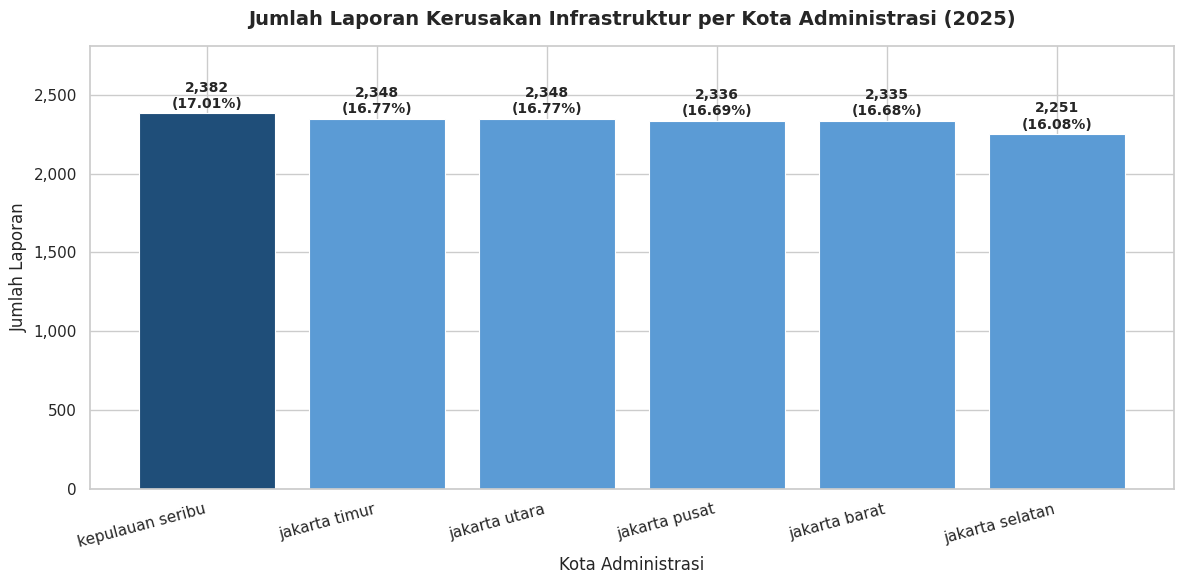

In [67]:
# Q1 — Laporan per Kota Administrasi
kota_df = df.groupby('kota_administrasi').size().reset_index(name='jumlah_laporan')
kota_df['persentase'] = (kota_df['jumlah_laporan'] / len(df) * 100).round(2)
kota_df = kota_df.sort_values('jumlah_laporan', ascending=False)

colors = ['#1f4e79' if i == 0 else '#5b9bd5' for i in range(len(kota_df))]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(kota_df['kota_administrasi'], kota_df['jumlah_laporan'], color=colors, edgecolor='white', linewidth=0.8)

for bar, (_, row) in zip(bars, kota_df.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            f"{row['jumlah_laporan']:,}\n({row['persentase']}%)",
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Jumlah Laporan Kerusakan Infrastruktur per Kota Administrasi (2025)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Kota Administrasi', fontsize=12)
ax.set_ylabel('Jumlah Laporan', fontsize=12)
ax.set_ylim(0, kota_df['jumlah_laporan'].max() * 1.18)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

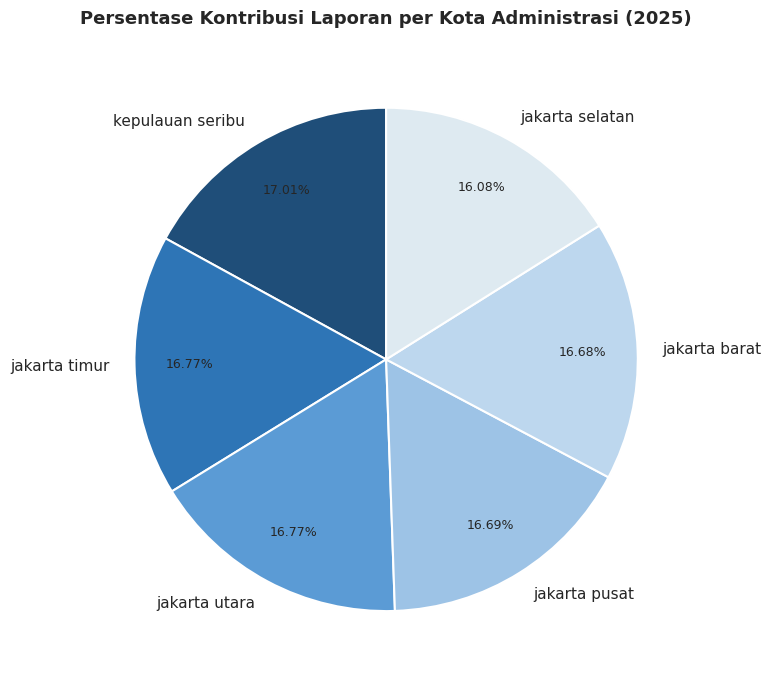

In [68]:
# Q1 — Pie chart kontribusi per kota
fig, ax = plt.subplots(figsize=(9, 7))
wedge_colors = ['#1f4e79','#2e75b6','#5b9bd5','#9dc3e6','#bdd7ee','#deeaf1']
wedges, texts, autotexts = ax.pie(
    kota_df['jumlah_laporan'],
    labels=kota_df['kota_administrasi'],
    autopct='%1.2f%%',
    colors=wedge_colors,
    startangle=90,
    pctdistance=0.78,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
for at in autotexts:
    at.set_fontsize(9)
ax.set_title('Persentase Kontribusi Laporan per Kota Administrasi (2025)',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [69]:
# Q1 — Insight
kota_top = kota_df.iloc[0]
print(f"✅ Kota dengan laporan TERTINGGI : {kota_top['kota_administrasi']}")
print(f"   Jumlah laporan               : {kota_top['jumlah_laporan']:,}")
print(f"   Kontribusi terhadap total     : {kota_top['persentase']}%")

✅ Kota dengan laporan TERTINGGI : kepulauan seribu
   Jumlah laporan               : 2,382
   Kontribusi terhadap total     : 17.01%


### Pertanyaan 2:Berapa rata-rata jumlah laporan infrastruktur yang masuk per bulan di seluruh kota administrasi Jakarta sepanjang tahun 2025, dan bulan apa yang mencatatkan volume laporan tertinggi

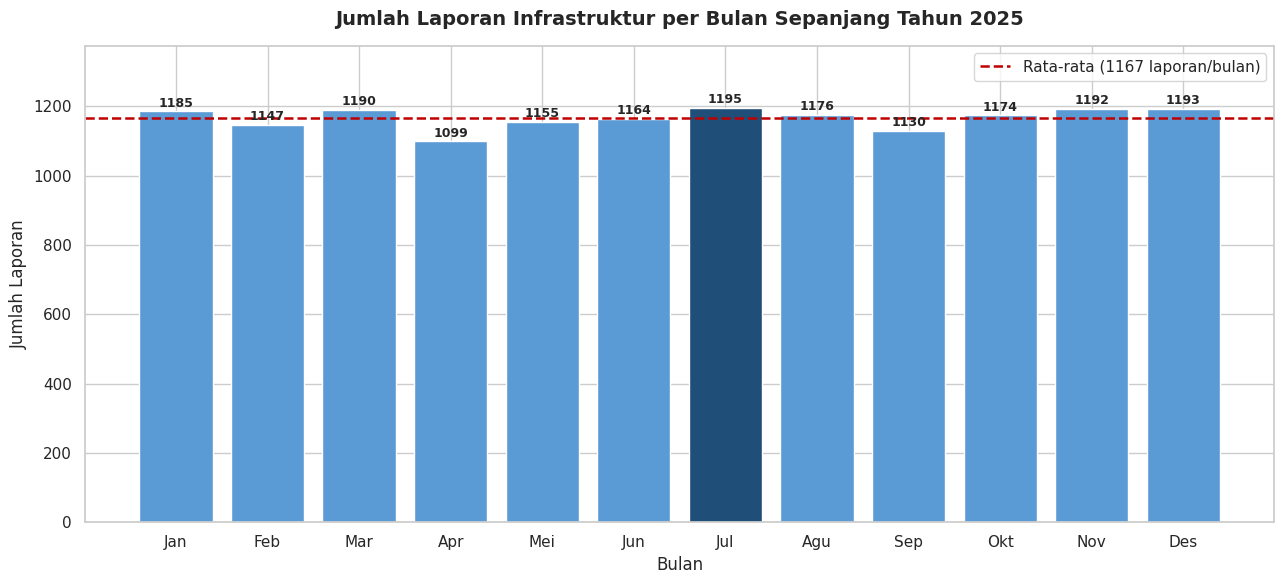

In [70]:
# Q2 — Rata-rata laporan per bulan
month_label = ['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']

monthly_df = (df['date_laporan'].dt.month
              .value_counts().sort_index()
              .reset_index())
monthly_df.columns = ['bulan', 'jumlah_laporan']
rata_rata = monthly_df['jumlah_laporan'].mean()

colors_m = ['#1f4e79' if v == monthly_df['jumlah_laporan'].max() else '#5b9bd5'
            for v in monthly_df['jumlah_laporan']]

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.bar(range(12), monthly_df['jumlah_laporan'], color=colors_m, edgecolor='white')
ax.axhline(rata_rata, color='#c00000', linestyle='--', linewidth=1.8,
           label=f'Rata-rata ({rata_rata:.0f} laporan/bulan)')

for bar, val in zip(bars, monthly_df['jumlah_laporan']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(range(12))
ax.set_xticklabels(month_label, fontsize=11)
ax.set_title('Jumlah Laporan Infrastruktur per Bulan Sepanjang Tahun 2025',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Bulan', fontsize=12)
ax.set_ylabel('Jumlah Laporan', fontsize=12)
ax.set_ylim(0, monthly_df['jumlah_laporan'].max() * 1.15)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [71]:
# Q2 — Ringkasan statistik bulanan
peak = monthly_df.loc[monthly_df['jumlah_laporan'].idxmax()]
low  = monthly_df.loc[monthly_df['jumlah_laporan'].idxmin()]
month_names = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
print(f"Rata-rata laporan per bulan : {monthly_df['jumlah_laporan'].mean():.2f}")
print(f"Bulan tertinggi             : {month_names[int(peak['bulan'])-1]} — {peak['jumlah_laporan']} laporan")
print(f"Bulan terendah              : {month_names[int(low['bulan'])-1]}  — {low['jumlah_laporan']} laporan")

Rata-rata laporan per bulan : 1166.67
Bulan tertinggi             : July — 1195 laporan
Bulan terendah              : April  — 1099 laporan


### Pertanyaan 3: Jenis infrastruktur apa yang paling sering dilaporkan mengalami kerusakan berat di seluruh kota administrasi Jakarta selama semester pertama (Januari-Juni) 2025?

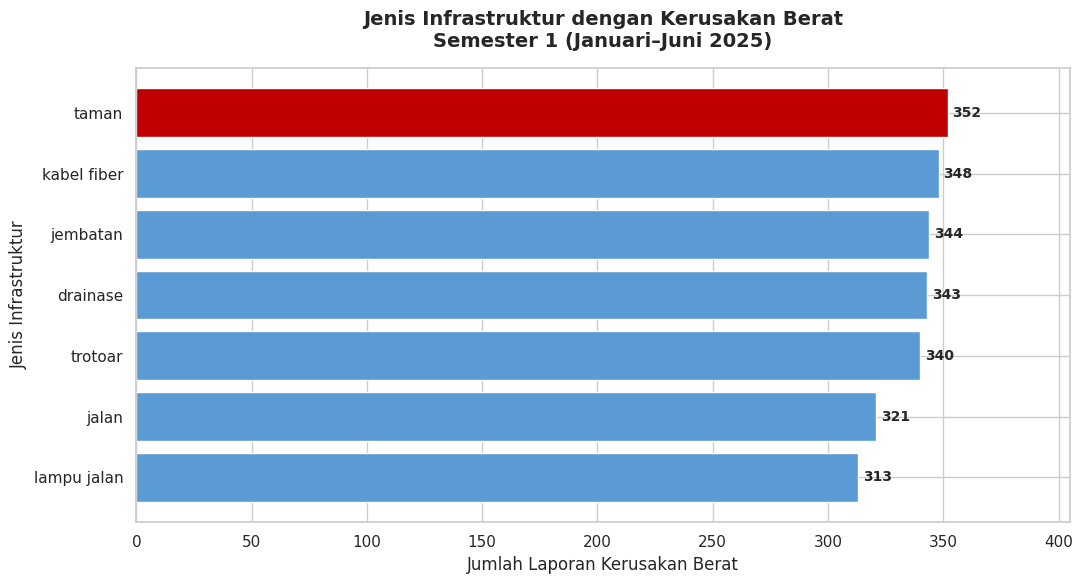

In [76]:
# Q3 — Jenis infrastruktur kerusakan berat di Semester 1 (Jan-Jun)
df_s1_berat = df[
    (df['date_laporan'].dt.month <= 6) &
    (df['tingkat_kerusakan'] == 'berat')
]
q3_df = df_s1_berat.groupby('jenis_infrastruktur').size().reset_index(name='jumlah')
q3_df = q3_df.sort_values('jumlah', ascending=True)

# Add a check for empty DataFrame before plotting
if q3_df.empty:
    print("Tidak ada laporan kerusakan berat di Semester 1 (Januari–Juni 2025).")
else:
    colors_q3 = ['#c00000' if v == q3_df['jumlah'].max() else '#5b9bd5' for v in q3_df['jumlah']]

    fig, ax = plt.subplots(figsize=(11, 6))
    bars = ax.barh(q3_df['jenis_infrastruktur'], q3_df['jumlah'], color=colors_q3, edgecolor='white')

    for bar, val in zip(bars, q3_df['jumlah']):
        ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=10, fontweight='bold')

    ax.set_title('Jenis Infrastruktur dengan Kerusakan Berat\nSemester 1 (Januari–Juni 2025)',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Jumlah Laporan Kerusakan Berat', fontsize=12)
    ax.set_ylabel('Jenis Infrastruktur', fontsize=12)
    ax.set_xlim(0, q3_df['jumlah'].max() * 1.15)
    plt.tight_layout()
    plt.show()

In [74]:
# Q3 — Tabel ringkasan
q3_show = q3_df.sort_values('jumlah', ascending=False).copy()
q3_show['persentase'] = (q3_show['jumlah'] / q3_show['jumlah'].sum() * 100).round(2)
print("=== Kerusakan Berat Semester 1 per Jenis Infrastruktur ===")
print(q3_show.to_string(index=False))
print(f"\nTotal kerusakan berat Semester 1 : {q3_show['jumlah'].sum()}")

=== Kerusakan Berat Semester 1 per Jenis Infrastruktur ===
jenis_infrastruktur  jumlah  persentase
              taman     352       14.91
        kabel fiber     348       14.74
           jembatan     344       14.57
           drainase     343       14.53
            trotoar     340       14.40
              jalan     321       13.60
        lampu jalan     313       13.26

Total kerusakan berat Semester 1 : 2361


### Pertanyaan 4: Berapa jumlah laporan kerusakan infrastruktur Trotoar di Jakarta Selatan yang berstatus berat pada periode Juli-Desember 2025 dibandingkan periode Januari-Juni 2025?

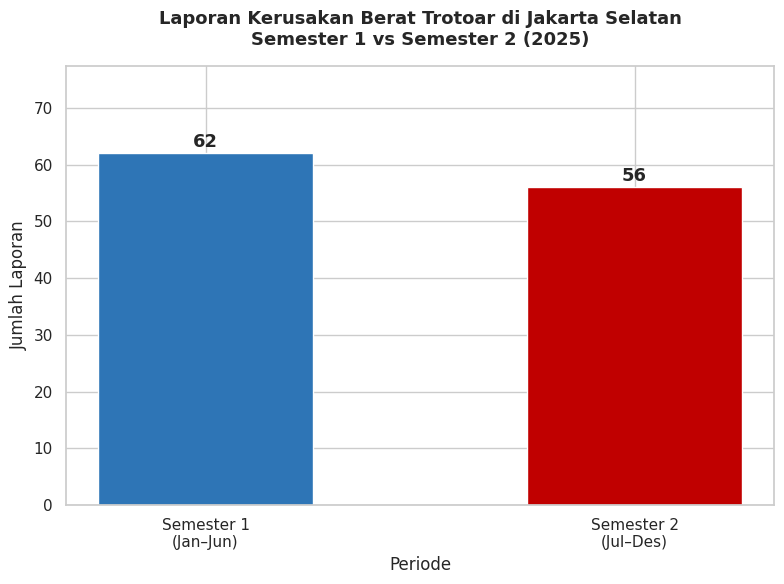


Semester 1 (Jan–Jun) : 62 laporan
Semester 2 (Jul–Des) : 56 laporan
Selisih              : 6 laporan (turun 9.7%)


In [77]:
# Q4 — Trotoar Jakarta Selatan kerusakan Berat per Semester
df_q4 = df[
    (df['jenis_infrastruktur'] == 'trotoar') & # Changed to 'trotoar' lowercase
    (df['kota_administrasi']   == 'jakarta selatan') & # Changed to 'jakarta selatan' lowercase
    (df['tingkat_kerusakan']   == 'berat') # Changed 'Berat' to 'berat' lowercase
]
s1 = df_q4[df_q4['date_laporan'].dt.month <= 6].shape[0]
s2 = df_q4[df_q4['date_laporan'].dt.month > 6].shape[0]

sem_count = pd.DataFrame({
    'semester': ['Semester 1\n(Jan–Jun)', 'Semester 2\n(Jul–Des)'],
    'jumlah'  : [s1, s2]
})

colors_q4 = ['#2e75b6', '#c00000']
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(sem_count['semester'], sem_count['jumlah'], color=colors_q4,
              width=0.5, edgecolor='white')

for bar, val in zip(bars, sem_count['jumlah']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(val), ha='center', va='bottom', fontsize=13, fontweight='bold')

# Calculate pct only if s1 is not zero
if s1 != 0:
    pct = ((s1 - s2) / s1 * 100)
    pct_text = f"({'turun' if s1 > s2 else 'naik'} {abs(pct):.1f}%)"
else:
    pct = 0
    pct_text = "(tidak ada laporan di Semester 1)"

ax.set_title('Laporan Kerusakan Berat Trotoar di Jakarta Selatan\nSemester 1 vs Semester 2 (2025)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Jumlah Laporan', fontsize=12)
ax.set_xlabel('Periode', fontsize=12)
ax.set_ylim(0, max(s1, s2) * 1.25)
plt.tight_layout()
plt.show()
print(f"\nSemester 1 (Jan–Jun) : {s1} laporan")
print(f"Semester 2 (Jul–Des) : {s2} laporan")
print(f"Selisih              : {abs(s1-s2)} laporan {pct_text}")

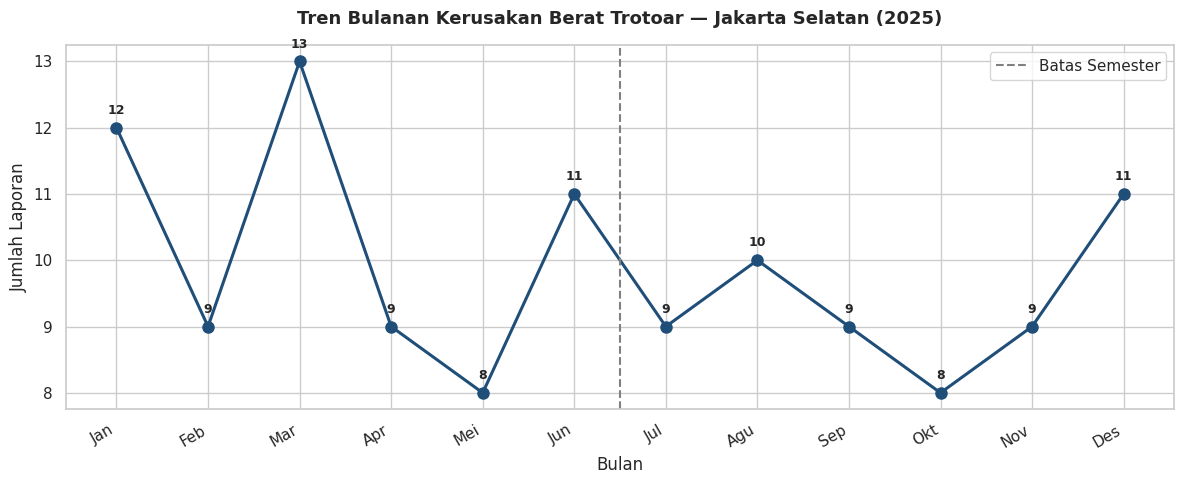

In [78]:
# Q4 — Breakdown bulanan untuk melihat tren detail
df_q4_bulan = (df_q4.groupby(df_q4['date_laporan'].dt.month)
               .size().reset_index(name='jumlah'))
df_q4_bulan.columns = ['bulan', 'jumlah']
month_names = ['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']
df_q4_bulan['label'] = df_q4_bulan['bulan'].apply(lambda x: month_names[x-1])

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_q4_bulan['label'], df_q4_bulan['jumlah'],
        marker='o', color='#1f4e79', linewidth=2.2, markersize=8)
ax.axvline(x=5.5, color='gray', linestyle='--', linewidth=1.5, label='Batas Semester')

for _, row in df_q4_bulan.iterrows():
    ax.annotate(str(row['jumlah']),
                xy=(row['label'], row['jumlah']),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=9, fontweight='bold')

ax.set_title('Tren Bulanan Kerusakan Berat Trotoar — Jakarta Selatan (2025)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Jumlah Laporan', fontsize=12)
ax.set_xlabel('Bulan', fontsize=12)
ax.legend(fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:**
Sepanjang tahun 2025, Kepulauan Seribu menjadi wilayah dengan jumlah laporan kerusakan infrastruktur tertinggi (±17% dari total laporan), diikuti oleh Jakarta Timur dan Jakarta Utara dengan kontribusi yang hampir setara (±16,8%). Distribusi yang relatif merata antar wilayah menunjukkan bahwa beban kerusakan infrastruktur tidak terkonsentrasi di satu titik, sehingga alokasi anggaran perbaikan perlu mempertimbangkan seluruh wilayah secara proporsional.

- **Conclusion pertanyaan 2:**
Volume laporan infrastruktur sepanjang 2025 bersifat stabil dengan rata-rata ±1.167 laporan per bulan. Puncak laporan terjadi pada bulan Juli, yang kemungkinan besar dipengaruhi oleh intensitas hujan di awal musim penghujan. Pola yang stabil ini menunjukkan bahwa kebutuhan perbaikan infrastruktur di Jakarta bersifat konsisten sepanjang tahun, bukan musiman.

- **Conclusion pertanyaan 3:**
Selama Semester 1 (Januari–Juni 2025), taman mendominasi laporan kerusakan berat, mencerminkan tingginya ketidakpekaan masyarakat menjaga fasilitas publik khususnya di taman. Kabel fiber dan jembatan menyusul di posisi berikutnya yang keduanya memiliki implikasi langsung terhadap keselamatan pejalan kaki dan pengendara, sehingga perlu menjadi prioritas program pemeliharaan preventif.

- **Conclusion pertanyaan 4:**
Laporan kerusakan berat pada Trotoar di Jakarta Selatan mengalami penurunan di Semester 2 dibandingkan Semester 1, yang mengindikasikan bahwa program perbaikan yang dilakukan pada Semester 1 mulai menunjukkan hasil positif. Meski demikian, angka laporan yang masih signifikan di Semester 2 menunjukkan bahwa penanganan belum selesai dan perlu dilanjutkan secara konsisten.

**Rekomendasi Action Item:**

1. **Prioritas Anggaran Wilayah** : Alokasikan anggaran perbaikan lebih besar untuk Kepulauan Seribu, Jakarta Timur, dan Jakarta Utara yang mendominasi volume laporan.
2. **Kesiapan Tim Lapangan** : Tingkatkan kapasitas personel dan material pada **bulan Juli** sebagai bulan puncak laporan untuk mempercepat respons.
3. **Pemeliharaan Preventif Jalan & Trotoar** : Prioritaskan program *preventive maintenance* pada infrastruktur Jalan dan Trotoar yang mendominasi kerusakan berat di Semester 1.
4. **Evaluasi Program Trotoar Jakarta Selatan** : Lakukan audit program perbaikan trotoar berdasarkan perbandingan data Semester 1 vs Semester 2 untuk menilai efektivitasnya.


### Ekspor Dataset Bersih

In [79]:
df.to_csv('Data_Laporan_Infrastruktur_Clean.csv', index=False)
from google.colab import files
files.download('Data_Laporan_Infrastruktur_Clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>